# 쌍체 표본 t 검정

- 다이어트 전과 후의 차이가 유의한지 검정하기

## 가설 설정

- 귀무가설 : 다이어트 전 과 후의 차이가 없다.
- 대립가설 : 다이어트 전 과 후의 차이가 있다.

In [19]:
import pandas as pd

In [20]:
df = pd.read_csv("datas2/다이어트약_효과검증.csv", encoding='utf-8')

In [21]:
df.columns

Index(['다이어트전(kg)', '다이어트후(kg)'], dtype='str')

In [ ]:
before = df['다이어트전(kg)']
after = df['다이어트후(kg)']

## 정규성 검정
- A와 B 두 그룹간의 차이가 정규분포를 따르는지 판단하기
- 방법1 : Shapiro-Wilk 검정

In [23]:
from scipy import stats

stats.shapiro(after-before)

ShapiroResult(statistic=np.float64(0.9724073061836589), pvalue=np.float64(0.28920934252823394))

[해석]

p-value > 0.05 이므로, 정규분포를 따른다는 것을 알 수 있음
방법2 : D'Agostino-Pearson 검정

In [24]:
stats.normaltest(after - before)

NormaltestResult(statistic=np.float64(2.079777506462687), pvalue=np.float64(0.35349400483724547))

[해석]

0.35349400483724547

p-value > 0.05 이므로, 정규분포를 따른다는 것을 알 수 있음

## 쌍체 표본 t 검정

In [30]:
stats.ttest_rel(before,after)
# 같은 대상에게서 처치 전/후처럼 짝지어진(paired) 두 값을 비교할 때
## ttest_rel: 같은 대상의 전/후 비교(쌍체), 등분산성 확인 불필요 (같은 대상이므로)

# ttest_ind : 서로 독립적인 두 그룹(예: A반 vs B반)을 비교
## ttest_ind: 서로 다른(독립된) 두 그룹 비교, 등분산성 확인 필요

TtestResult(statistic=np.float64(9.70596986565785), pvalue=np.float64(5.370404098342336e-13), df=np.int64(49))

- 5.370404098342336e-13 
5.370404098342336e-13 = 5.370404098342336 × 10⁻¹³
소수점 왼쪽으로 13칸 옮긴다.

참고: e 표기법 읽는 법

e-13 → 소수점을 왼쪽으로 13칸 (아주 작은 수)
e+13 또는 e13 → 소수점을 오른쪽으로 13칸 (아주 큰 수)

예시:

1e-3 = 0.001
1e3 = 1000
2.5e-2 = 0.025

- p-value <= 0.05 : 귀무가설을 기각함
    - 두 집단의 평균 차이가 통계적으로 유의함.
    - 다이어트 효과가 있다. (대립가설 채택)

- h0 : d = 0, h1 : d != 0
- 통계량이 양수 이기 때문에 양의 효과 있다는 것을 알 수 있음

In [26]:
import numpy as np
np.mean(before), np.mean(after)

(np.float64(73.4002), np.float64(69.0636))

In [27]:
np.mean(before) - np.mean(after)

np.float64(4.336600000000004)

표본 t 통계량 공식 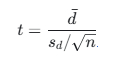

In [28]:
# 전후 차이 계산(개인별 체중 차이)
diff = before - after

# 체중 차이의 평균 계산(평균 체중 감소량)
mean_diff = np.mean(diff)

# 체중 차이의 표준편차(감소량의 표준편차)
std_diff = np.std(diff, ddof=1)

# 체중 차이의 표준오차(표본에서 구한 평균 체중 감소량의 불확실성을 나타냄)
standard_error = std_diff / np.sqrt(len(diff))

# t-통계량 계산(평균 체중 감소량이 표준오차보다 몇 배 큰지를 나타냄)
t_statistic = mean_diff / standard_error
t_statistic

np.float64(9.70596986565785)

In [29]:
# 계산 결과 출력
print(mean_diff)       # 평균 체중 감소량
print(std_diff)        # 체중 감소량의 표준편차
print(standard_error)  # 평균 체중 감소량의 표준오차
print(t_statistic)     # t 통계량

4.336600000000001
3.1593331833260803
0.44679718359151066
9.70596986565785
